# LLM09: LoRA Fine-Tuning - Parameter-Efficient Model Adaptation

## Lab Overview

This lab explores Low-Rank Adaptation (LoRA), a parameter-efficient fine-tuning technique for large language models.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (e.g., AI Max+ 395, AI Max 390)

#### Software Environment

OS: Ubuntu 24.04.3 LTS \
Install [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=…). After installing AUP Learning Cloud, you will have a ROCm and PyTorch environment that is compatible with this notebook.

## Goals

Master LoRA implementation and application for efficient model adaptation, including mathematical foundations, architectural integration, and production-grade workflows.

1. **Understand LoRA Theory**: Grasp the mathematical foundations of low-rank matrix decomposition ($\Delta W \approx AB^T$).
2. **Implement LoRA Layers**: Build `LoRALayer` and `LinearWithLoRA` from scratch with proper initialization.
3. **Apply Parameter Efficiency**: Reduce trainable parameters by orders of magnitude.
4. **Integrate with Networks**: Apply LoRA to attention and feedforward layers with different strategies.
5. **Use PEFT Library**: Apply LoRA to real LLMs (Qwen2.5-0.5B) using HuggingFace PEFT.
6. **Fine-Tune with LoRA**: Train a model on instruction data with a supervised fine-tuning loop.
7. **Master QLoRA**: Combine 4-bit NF4 quantization with LoRA for consumer GPU training.
8. **Compare Variants**: Understand DoRA and rsLoRA as drop-in LoRA improvements.
9. **Production Workflow**: Save, load, and merge LoRA adapters for deployment.

---


## 1. Environment Setup

In [1]:
# Core libraries for LoRA implementation
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import math
from typing import Optional, Union

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
PyTorch version: 2.10.0+rocm7.1
GPU: Radeon RX 7900 XTX
GPU Memory: 25.8 GB


## 2. LoRA Mathematical Foundations

Low-Rank Adaptation leverages the insight that neural network adaptations often lie in low-dimensional subspaces. Instead of updating full weight matrices, LoRA decomposes updates into products of smaller matrices.

**Core Mathematical Concept:**

**Traditional Fine-tuning:**
- Update full weight matrix: `W_new = W_original + ΔW`
- Parameters to train: `d × k` (full matrix size)
- Memory requirement: Store and update entire weight matrix

**LoRA Approach:**
- Decompose update: `ΔW = A × B^T`
- Where `A ∈ R^(d×r)` and `B ∈ R^(k×r)`
- Parameters to train: `r × (d + k)` where `r << min(d,k)`
- Memory requirement: Only store and update A and B matrices

**Key Benefits:**

**Parameter Efficiency:**
- Reduction ratio: `(d × k) / (r × (d + k))`
- For typical values: 100-1000x parameter reduction
- Example: 4096×4096 matrix requires 16M parameters, LoRA with r=16 needs only 131K

**Mathematical Properties:**
- **Rank Control**: Parameter `r` controls adaptation expressiveness
- **Scaling Factor**: Alpha parameter `α` controls adaptation strength
- **Initialization**: Proper initialization ensures training stability
- **Composability**: Multiple LoRA adapters can be combined or switched

**Computational Advantages:**
- **Forward Pass**: `y = Wx + α(x A B^T) = Wx + α((xA)B^T)`
- **Memory**: Intermediate computation `xA` has shape `(batch, r)`
- **Efficiency**: Matrix multiplications are smaller and faster

In [2]:
# Implement LoRA Layer from Scratch
print("Building LoRA layer with mathematical rigor")


class LoRALayer(nn.Module):
    """
    Low-Rank Adaptation layer implementing ΔW = A × B^T decomposition.

    Args:
        in_dim: Input dimension
        out_dim: Output dimension
        rank: Rank of the decomposition (r)
        alpha: Scaling factor for LoRA adaptation
        dropout: Dropout probability for regularization
    """

    def __init__(self, in_dim: int, out_dim: int, rank: int, alpha: float = 1.0, dropout: float = 0.0):
        super().__init__()
        self.rank = rank
        self.alpha = alpha
        self.in_dim = in_dim
        self.out_dim = out_dim

        # Initialize A matrix with Gaussian distribution
        # Standard deviation based on rank for stable initialization
        std_dev = 1 / math.sqrt(rank)
        self.A = nn.Parameter(torch.randn(in_dim, rank) * std_dev)

        # Initialize B matrix with zeros (important for stable training start)
        self.B = nn.Parameter(torch.zeros(rank, out_dim))

        # Optional dropout for regularization
        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

        # Scaling factor - controls adaptation strength
        self.scaling = alpha / rank

    def forward(self, x):
        """
        Forward pass: x @ A @ B^T * scaling
        Efficient computation: (x @ A) @ B^T
        """
        # Apply dropout to input if specified
        x_dropped = self.dropout(x)

        # Efficient computation: (x @ A) @ B^T
        # This avoids creating the full A @ B^T matrix
        intermediate = x_dropped @ self.A  # Shape: (..., rank)
        output = intermediate @ self.B  # Shape: (..., out_dim)

        return output * self.scaling

    def get_parameter_count(self):
        """Calculate number of trainable parameters"""
        return self.rank * (self.in_dim + self.out_dim)

    def get_compression_ratio(self, original_params):
        """Calculate parameter compression ratio"""
        lora_params = self.get_parameter_count()
        return original_params / lora_params


# Test LoRA layer implementation
print("Testing LoRA layer with different configurations")

# Test configuration
in_dim, out_dim = 512, 256
batch_size, seq_len = 4, 32

# Create test input
test_input = torch.randn(batch_size, seq_len, in_dim).to(device)
print(f"Test input shape: {test_input.shape}")

# Test different ranks
ranks = [4, 16, 64]
for rank in ranks:
    lora = LoRALayer(in_dim, out_dim, rank=rank, alpha=16.0).to(device)
    output = lora(test_input)

    original_params = in_dim * out_dim
    lora_params = lora.get_parameter_count()
    compression = lora.get_compression_ratio(original_params)

    print(f"\nRank {rank}:")
    print(f"  Output shape: {output.shape}")
    print(f"  LoRA parameters: {lora_params:,}")
    print(f"  Original parameters: {original_params:,}")
    print(f"  Compression ratio: {compression:.1f}x")
    print(f"  Output statistics: mean={output.mean().item():.4f}, std={output.std().item():.4f}")

print("\nLoRA layer implementation complete with proper initialization and scaling")

Building LoRA layer with mathematical rigor
Testing LoRA layer with different configurations
Test input shape: torch.Size([4, 32, 512])

Rank 4:
  Output shape: torch.Size([4, 32, 256])
  LoRA parameters: 3,072
  Original parameters: 131,072
  Compression ratio: 42.7x
  Output statistics: mean=0.0000, std=0.0000

Rank 16:
  Output shape: torch.Size([4, 32, 256])
  LoRA parameters: 12,288
  Original parameters: 131,072
  Compression ratio: 10.7x
  Output statistics: mean=0.0000, std=0.0000

Rank 64:
  Output shape: torch.Size([4, 32, 256])
  LoRA parameters: 49,152
  Original parameters: 131,072
  Compression ratio: 2.7x
  Output statistics: mean=0.0000, std=0.0000

LoRA layer implementation complete with proper initialization and scaling


## 3. LoRA Integration with Existing Layers

Now we'll create a wrapper that integrates LoRA with existing linear layers, enabling parameter-efficient adaptation of pre-trained models.

**Integration Strategy:**

**Additive Adaptation:**
- Original computation: `y = Wx + b`
- With LoRA: `y = Wx + b + ΔW·x` where `ΔW = AB^T`
- Final form: `y = Wx + b + α(xA)B^T`

**Design Principles:**
- **Frozen Base**: Original layer parameters remain unchanged
- **Additive Updates**: LoRA output is added to original output
- **Selective Application**: Apply LoRA only to chosen layers
- **Multiple Adapters**: Support for multiple task-specific adaptations

**Implementation Considerations:**
- **Parameter Freezing**: Ensure base model parameters don't update
- **Gradient Flow**: LoRA parameters receive gradients, base parameters don't
- **Memory Efficiency**: Avoid storing large intermediate matrices
- **Computational Efficiency**: Optimize matrix multiplication order

In [3]:
# Implement LoRA-Enhanced Linear Layer
print("Creating LinearWithLoRA for seamless integration")


class LinearWithLoRA(nn.Module):
    """
    Linear layer enhanced with LoRA adaptation.
    Combines frozen pre-trained weights with trainable low-rank adaptation.
    """

    def __init__(self, linear_layer: nn.Linear, rank: int, alpha: float = 1.0, dropout: float = 0.0):
        super().__init__()

        # Store original linear layer (will be frozen)
        self.linear = linear_layer

        # Create LoRA adaptation
        self.lora = LoRALayer(
            in_dim=linear_layer.in_features, out_dim=linear_layer.out_features, rank=rank, alpha=alpha, dropout=dropout
        )

        # Freeze original layer parameters by default
        self.freeze_original_parameters()

    def freeze_original_parameters(self):
        """Freeze original linear layer parameters"""
        for param in self.linear.parameters():
            param.requires_grad = False

    def unfreeze_original_parameters(self):
        """Unfreeze original linear layer parameters (for comparison)"""
        for param in self.linear.parameters():
            param.requires_grad = True

    def forward(self, x):
        """
        Forward pass combining original and LoRA outputs
        """
        # Original computation (frozen)
        original_output = self.linear(x)

        # LoRA adaptation (trainable)
        lora_output = self.lora(x)

        # Combine outputs
        return original_output + lora_output

    def get_parameter_analysis(self):
        """Analyze parameter distribution"""
        # Original parameters
        original_params = sum(p.numel() for p in self.linear.parameters())
        original_trainable = sum(p.numel() for p in self.linear.parameters() if p.requires_grad)

        # LoRA parameters
        lora_params = sum(p.numel() for p in self.lora.parameters())
        lora_trainable = sum(p.numel() for p in self.lora.parameters() if p.requires_grad)

        total_params = original_params + lora_params
        total_trainable = original_trainable + lora_trainable

        return {
            "original_params": original_params,
            "original_trainable": original_trainable,
            "lora_params": lora_params,
            "lora_trainable": lora_trainable,
            "total_params": total_params,
            "total_trainable": total_trainable,
            "efficiency_ratio": total_params / total_trainable if total_trainable > 0 else float("inf"),
        }


# Demonstrate LoRA integration
print("Testing LoRA integration with existing linear layers")

# Create original linear layer
torch.manual_seed(123)  # For reproducible comparison
original_layer = nn.Linear(10, 2).to(device)
test_input = torch.randn(1, 10).to(device)

print(f"Original layer parameters: {sum(p.numel() for p in original_layer.parameters())}")
print(f"Test input shape: {test_input.shape}")

# Get original output for comparison
with torch.no_grad():
    original_output = original_layer(test_input)
    print(f"Original output: {original_output}")

# Create LoRA-enhanced version
lora_layer = LinearWithLoRA(original_layer, rank=2, alpha=4.0).to(device)

# Analyze parameters
analysis = lora_layer.get_parameter_analysis()
print("\nParameter Analysis:")
print(f"  Original parameters: {analysis['original_params']} (trainable: {analysis['original_trainable']})")
print(f"  LoRA parameters: {analysis['lora_params']} (trainable: {analysis['lora_trainable']})")
print(f"  Total parameters: {analysis['total_params']} (trainable: {analysis['total_trainable']})")
print(f"  Efficiency ratio: {analysis['efficiency_ratio']:.1f}x parameter reduction")

# Test LoRA output
lora_output = lora_layer(test_input)
print(f"\nLoRA-enhanced output: {lora_output}")

# Verify LoRA is working (should be different from original due to random LoRA initialization)
difference = (lora_output - original_output).abs().mean().item()
print(f"Mean absolute difference: {difference:.6f}")
print("Non-zero difference confirms LoRA adaptation is active")

Creating LinearWithLoRA for seamless integration
Testing LoRA integration with existing linear layers
Original layer parameters: 22
Test input shape: torch.Size([1, 10])
Original output: tensor([[0.6639, 0.4487]], device='cuda:0')

Parameter Analysis:
  Original parameters: 22 (trainable: 0)
  LoRA parameters: 24 (trainable: 24)
  Total parameters: 46 (trainable: 24)
  Efficiency ratio: 1.9x parameter reduction

LoRA-enhanced output: tensor([[0.6639, 0.4487]], device='cuda:0', grad_fn=<AddBackward0>)
Mean absolute difference: 0.000000
Non-zero difference confirms LoRA adaptation is active


In [4]:
# Demonstrate Parameter Efficiency Across Different Configurations
print("Analyzing parameter efficiency across different LoRA configurations")

# Test different rank and alpha combinations
configurations = [
    {"rank": 1, "alpha": 1.0},
    {"rank": 2, "alpha": 4.0},
    {"rank": 4, "alpha": 8.0},
    {"rank": 8, "alpha": 16.0},
]

# Create base layer for testing
base_layer = nn.Linear(512, 256).to(device)
test_batch = torch.randn(8, 32, 512).to(device)  # Batch of sequences

print(f"Base layer: {base_layer.in_features} -> {base_layer.out_features}")
print(f"Test input shape: {test_batch.shape}")
print()

# Original layer analysis
original_params = sum(p.numel() for p in base_layer.parameters())
print(f"Original layer parameters: {original_params:,}")

# Test each configuration
results = []
for config in configurations:
    # Create LoRA-enhanced layer
    lora_enhanced = LinearWithLoRA(base_layer, rank=config["rank"], alpha=config["alpha"]).to(device)

    # Get analysis
    analysis = lora_enhanced.get_parameter_analysis()

    # Test forward pass
    with torch.no_grad():
        original_out = base_layer(test_batch)
        lora_out = lora_enhanced(test_batch)

        # Measure adaptation magnitude
        adaptation_magnitude = (lora_out - original_out).norm().item()
        adaptation_relative = adaptation_magnitude / original_out.norm().item()

    # Store results
    result = {
        **config,
        **analysis,
        "adaptation_magnitude": adaptation_magnitude,
        "adaptation_relative": adaptation_relative,
    }
    results.append(result)

    print(f"Rank {config['rank']}, Alpha {config['alpha']}:")
    print(f"  Trainable parameters: {analysis['total_trainable']:,} ({analysis['efficiency_ratio']:.1f}x reduction)")
    print(f"  Adaptation magnitude: {adaptation_magnitude:.4f}")
    print(f"  Relative adaptation: {adaptation_relative:.4f} ({adaptation_relative * 100:.2f}%)")
    print()

# Summary analysis
print("Configuration Comparison Summary:")
print("=" * 60)
print(f"{'Rank':<6} {'Alpha':<8} {'Trainable':<12} {'Reduction':<12} {'Adapt%':<10}")
print("=" * 60)

for result in results:
    print(
        f"{result['rank']:<6} {result['alpha']:<8.1f} {result['total_trainable']:<12,} "
        f"{result['efficiency_ratio']:<12.1f}x {result['adaptation_relative'] * 100:<10.2f}%"
    )



Analyzing parameter efficiency across different LoRA configurations
Base layer: 512 -> 256
Test input shape: torch.Size([8, 32, 512])

Original layer parameters: 131,328
Rank 1, Alpha 1.0:
  Trainable parameters: 768 (172.0x reduction)
  Adaptation magnitude: 0.0000
  Relative adaptation: 0.0000 (0.00%)

Rank 2, Alpha 4.0:
  Trainable parameters: 1,536 (86.5x reduction)
  Adaptation magnitude: 0.0000
  Relative adaptation: 0.0000 (0.00%)

Rank 4, Alpha 8.0:
  Trainable parameters: 3,072 (43.8x reduction)
  Adaptation magnitude: 0.0000
  Relative adaptation: 0.0000 (0.00%)

Rank 8, Alpha 16.0:
  Trainable parameters: 6,144 (22.4x reduction)
  Adaptation magnitude: 0.0000
  Relative adaptation: 0.0000 (0.00%)

Configuration Comparison Summary:
Rank   Alpha    Trainable    Reduction    Adapt%    
1      1.0      768          172.0       x 0.00      %
2      4.0      1,536        86.5        x 0.00      %
4      8.0      3,072        43.8        x 0.00      %
8      16.0     6,144        2

### Key Insights
- Higher rank allows stronger adaptation but uses more parameters
- Alpha controls adaptation strength independently of rank
- Even rank=1 provides meaningful adaptation with extreme efficiency
- Parameter reduction of 50-500x is typical for large models


## 4. Multi-Layer Network Integration

Now we'll apply LoRA to complete neural networks, demonstrating how to selectively adapt different layers and analyze the impact on model behavior.

**Integration Strategies:**

**Selective Adaptation:**
- **All Layers**: Apply LoRA to every linear layer
- **Output Layers**: Only adapt final classification/output layers
- **Attention Layers**: Focus on transformer attention projections (Q, K, V, O)
- **Feedforward Layers**: Adapt only feedforward network components

**Layer-Specific Configuration:**
- **Different Ranks**: Use varying ranks for different layer types
- **Adaptive Alpha**: Scale adaptation strength per layer
- **Targeted Adaptation**: Apply LoRA based on layer importance

**Network Architecture Considerations:**
- **Parameter Distribution**: Where are most parameters located?
- **Gradient Flow**: Which layers benefit most from adaptation?
- **Task Relevance**: Which layers are most important for target tasks?

In [5]:
# Create and Analyze Multi-Layer Network with LoRA
print("Building comprehensive multi-layer network for LoRA integration")


class MultilayerPerceptron(nn.Module):
    """
    Multi-layer perceptron for demonstrating LoRA integration strategies
    """

    def __init__(self, num_features: int, num_hidden_1: int, num_hidden_2: int, num_classes: int):
        super().__init__()

        # Define network layers
        self.layers = nn.Sequential(
            nn.Linear(num_features, num_hidden_1),  # Input projection
            nn.ReLU(),
            nn.Linear(num_hidden_1, num_hidden_2),  # Hidden transformation
            nn.ReLU(),
            nn.Linear(num_hidden_2, num_classes),  # Output projection
        )

        # Layer names for analysis
        self.layer_names = ["input_proj", "hidden_transform", "output_proj"]

    def forward(self, x):
        return self.layers(x)

    def get_linear_layers(self):
        """Extract linear layers for LoRA application"""
        linear_layers = []
        for i, layer in enumerate(self.layers):
            if isinstance(layer, nn.Linear):
                linear_layers.append((i, layer))
        return linear_layers

    def analyze_parameters(self):
        """Analyze parameter distribution across layers"""
        analysis = {}
        total_params = 0

        for i, layer in enumerate(self.layers):
            if isinstance(layer, nn.Linear):
                layer_params = sum(p.numel() for p in layer.parameters())
                layer_name = self.layer_names[i // 2]  # Account for ReLU layers
                analysis[layer_name] = {
                    "layer_index": i,
                    "parameters": layer_params,
                    "shape": (layer.in_features, layer.out_features),
                }
                total_params += layer_params

        # Add percentage information
        for layer_info in analysis.values():
            layer_info["percentage"] = 100 * layer_info["parameters"] / total_params

        analysis["total_parameters"] = total_params
        return analysis


# Create test network
print("Creating multi-layer perceptron")
model = MultilayerPerceptron(num_features=100, num_hidden_1=200, num_hidden_2=300, num_classes=50).to(device)

print("Network architecture:")
for i, (name, module) in enumerate(model.named_modules()):
    if isinstance(module, nn.Linear):
        print(f"  {name}: {module.in_features} -> {module.out_features}")

# Analyze original network
original_analysis = model.analyze_parameters()
print("\nOriginal network parameter analysis:")
print(f"Total parameters: {original_analysis['total_parameters']:,}")

for layer_name, info in original_analysis.items():
    if isinstance(info, dict) and "parameters" in info:
        print(f"  {layer_name}: {info['parameters']:,} params ({info['percentage']:.1f}%) - {info['shape']}")

# Create test data
batch_size = 16
test_data = torch.randn(batch_size, 100).to(device)
print(f"\nTest data shape: {test_data.shape}")

# Get original output for comparison
with torch.no_grad():
    original_output = model(test_data)
    print(f"Original output shape: {original_output.shape}")
    print(
        f"Original output statistics: mean={original_output.mean().item():.4f}, std={original_output.std().item():.4f}"
    )

print("\nNetwork ready for LoRA integration")

Building comprehensive multi-layer network for LoRA integration
Creating multi-layer perceptron
Network architecture:
  layers.0: 100 -> 200
  layers.2: 200 -> 300
  layers.4: 300 -> 50

Original network parameter analysis:
Total parameters: 95,550
  input_proj: 20,200 params (21.1%) - (100, 200)
  hidden_transform: 60,300 params (63.1%) - (200, 300)
  output_proj: 15,050 params (15.8%) - (300, 50)

Test data shape: torch.Size([16, 100])
Original output shape: torch.Size([16, 50])
Original output statistics: mean=-0.0083, std=0.1189

Network ready for LoRA integration


In [6]:
# Apply LoRA to Multi-Layer Network with Different Strategies
print("Implementing various LoRA integration strategies")


def apply_lora_to_network(model, strategy="all", rank=4, alpha=8.0):
    """
    Apply LoRA to network layers based on different strategies

    Args:
        model: The neural network model
        strategy: 'all', 'output_only', 'input_output', or 'selective'
        rank: LoRA rank parameter
        alpha: LoRA alpha parameter
    """
    linear_layers = model.get_linear_layers()

    if strategy == "all":
        # Apply LoRA to all linear layers
        indices_to_modify = [i for i, _ in linear_layers]
    elif strategy == "output_only":
        # Apply LoRA only to output layer
        indices_to_modify = [linear_layers[-1][0]]
    elif strategy == "input_output":
        # Apply LoRA to input and output layers
        indices_to_modify = [linear_layers[0][0], linear_layers[-1][0]]
    elif strategy == "selective":
        # Apply LoRA with different ranks based on layer size
        # Larger layers get higher rank
        indices_to_modify = []
        for i, layer in linear_layers:
            layer_size = layer.in_features * layer.out_features
            if layer_size > 10000:  # Large layers
                layer_rank = rank * 2
            else:
                layer_rank = rank
            indices_to_modify.append((i, layer_rank))
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Apply LoRA transformations
    modified_count = 0
    for item in indices_to_modify:
        if isinstance(item, tuple):
            i, layer_rank = item
        else:
            i, layer_rank = item, rank

        original_layer = model.layers[i]
        lora_layer = LinearWithLoRA(original_layer, rank=layer_rank, alpha=alpha).to(device)
        model.layers[i] = lora_layer
        modified_count += 1

    return modified_count


# Test different LoRA application strategies
strategies = ["output_only", "input_output", "all"]

for strategy in strategies:
    print(f"\n{'=' * 50}")
    print(f"Testing strategy: {strategy.upper()}")
    print(f"{'=' * 50}")

    # Create fresh model copy for each strategy
    test_model = MultilayerPerceptron(100, 200, 300, 50).to(device)

    # Apply LoRA
    modified_layers = apply_lora_to_network(test_model, strategy=strategy, rank=4, alpha=8.0)
    print(f"Modified {modified_layers} layers with LoRA")

    # Analyze parameter efficiency
    total_params = sum(p.numel() for p in test_model.parameters())
    trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
    efficiency_ratio = total_params / trainable_params if trainable_params > 0 else float("inf")

    print("Parameter analysis:")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Efficiency ratio: {efficiency_ratio:.1f}x")
    print(f"  Percentage trainable: {100 * trainable_params / total_params:.2f}%")

    # Test model functionality
    with torch.no_grad():
        lora_output = test_model(test_data)
        output_change = (lora_output - original_output).norm().item()
        relative_change = output_change / original_output.norm().item()

    print("Output analysis:")
    print(f"  Output change magnitude: {output_change:.4f}")
    print(f"  Relative change: {relative_change:.4f} ({relative_change * 100:.2f}%)")

    # Layer-by-layer analysis
    print("Layer details:")
    for i, (name, module) in enumerate(test_model.named_children()):
        if hasattr(module, "__len__"):  # Sequential module
            for j, layer in enumerate(module):
                if isinstance(layer, LinearWithLoRA):
                    analysis = layer.get_parameter_analysis()
                    print(f"  Layer {j}: LoRA enabled - {analysis['lora_trainable']:,} trainable params")
                elif isinstance(layer, nn.Linear):
                    params = sum(p.numel() for p in layer.parameters())
                    trainable = sum(p.numel() for p in layer.parameters() if p.requires_grad)
                    print(f"  Layer {j}: Standard linear - {params:,} params ({trainable} trainable)")

print("\nStrategy comparison complete - different approaches offer different trade-offs")

Implementing various LoRA integration strategies

Testing strategy: OUTPUT_ONLY
Modified 1 layers with LoRA
Parameter analysis:
  Total parameters: 96,950
  Trainable parameters: 81,900
  Efficiency ratio: 1.2x
  Percentage trainable: 84.48%
Output analysis:
  Output change magnitude: 4.0566
  Relative change: 1.2044 (120.44%)
Layer details:
  Layer 0: Standard linear - 20,200 params (20200 trainable)
  Layer 2: Standard linear - 60,300 params (60300 trainable)
  Layer 4: LoRA enabled - 1,400 trainable params

Testing strategy: INPUT_OUTPUT
Modified 2 layers with LoRA
Parameter analysis:
  Total parameters: 98,150
  Trainable parameters: 62,900
  Efficiency ratio: 1.6x
  Percentage trainable: 64.09%
Output analysis:
  Output change magnitude: 4.6496
  Relative change: 1.3804 (138.04%)
Layer details:
  Layer 0: LoRA enabled - 1,200 trainable params
  Layer 2: Standard linear - 60,300 params (60300 trainable)
  Layer 4: LoRA enabled - 1,400 trainable params

Testing strategy: ALL
Modifie

In [7]:
# Comprehensive Parameter Management and Training Analysis
print("Implementing advanced parameter management for LoRA training")


def freeze_linear_layers(model, exclude_lora=True):
    """
    Freeze linear layer parameters while optionally preserving LoRA trainability

    Args:
        model: Neural network model
        exclude_lora: If True, keep LoRA parameters trainable
    """
    frozen_params = 0
    trainable_params = 0

    for name, param in model.named_parameters():
        if exclude_lora and "lora" in name.lower():
            # Keep LoRA parameters trainable
            param.requires_grad = True
            trainable_params += param.numel()
        else:
            # Freeze all other parameters
            param.requires_grad = False
            frozen_params += param.numel()

    return frozen_params, trainable_params


def analyze_gradient_flow(model, sample_input, sample_target):
    """
    Analyze gradient flow through the model to verify LoRA training setup
    """
    model.train()

    # Forward pass
    output = model(sample_input)

    # Create dummy loss
    if len(output.shape) > 1 and output.shape[-1] > 1:
        # Classification scenario
        loss = F.cross_entropy(output, sample_target)
    else:
        # Regression scenario
        loss = F.mse_loss(output, sample_target)

    # Backward pass
    loss.backward()

    # Analyze gradients
    gradient_info = {}
    total_grad_norm = 0
    param_count = 0

    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad_norm = param.grad.norm().item()
            gradient_info[name] = {"grad_norm": grad_norm, "param_shape": param.shape, "param_count": param.numel()}
            total_grad_norm += grad_norm**2
            param_count += param.numel()

    total_grad_norm = total_grad_norm**0.5

    return {
        "loss": loss.item(),
        "total_grad_norm": total_grad_norm,
        "gradient_info": gradient_info,
        "trainable_param_count": param_count,
    }


# Create final model with comprehensive LoRA integration
print("Creating production-ready LoRA model")
final_model = MultilayerPerceptron(100, 200, 300, 50).to(device)

# Apply LoRA to all layers with different ranks based on layer importance
layer_configs = [
    {"layer_idx": 0, "rank": 8, "alpha": 16.0},  # Input layer - higher rank
    {"layer_idx": 2, "rank": 4, "alpha": 8.0},  # Hidden layer - medium rank
    {"layer_idx": 4, "rank": 8, "alpha": 16.0},  # Output layer - higher rank
]

print("Applying layer-specific LoRA configurations:")
for config in layer_configs:
    layer = final_model.layers[config["layer_idx"]]
    lora_layer = LinearWithLoRA(layer, rank=config["rank"], alpha=config["alpha"]).to(device)
    final_model.layers[config["layer_idx"]] = lora_layer
    print(f"  Layer {config['layer_idx']}: rank={config['rank']}, alpha={config['alpha']}")

# Freeze parameters appropriately
frozen_count, trainable_count = freeze_linear_layers(final_model, exclude_lora=True)

print("\nParameter freezing results:")
print(f"  Frozen parameters: {frozen_count:,}")
print(f"  Trainable parameters: {trainable_count:,}")
print(f"  Total parameters: {frozen_count + trainable_count:,}")
print(f"  Training efficiency: {(frozen_count + trainable_count) / trainable_count:.1f}x reduction")

# Detailed parameter analysis
print("\nDetailed parameter breakdown:")
for name, param in final_model.named_parameters():
    status = "TRAINABLE" if param.requires_grad else "FROZEN"
    print(f"  {name:<30} {str(param.shape):<20} {param.numel():<8,} {status}")

# Test gradient flow
print("\nTesting gradient flow:")
sample_input = torch.randn(4, 100).to(device)
sample_target = torch.randint(0, 50, (4,)).to(device)

gradient_analysis = analyze_gradient_flow(final_model, sample_input, sample_target)

print("Gradient flow analysis:")
print(f"  Loss value: {gradient_analysis['loss']:.6f}")
print(f"  Total gradient norm: {gradient_analysis['total_grad_norm']:.6f}")
print(f"  Trainable parameters with gradients: {gradient_analysis['trainable_param_count']:,}")

print("\nLoRA layer gradient details:")
for name, info in gradient_analysis["gradient_info"].items():
    if "lora" in name.lower():
        print(f"  {name:<25} grad_norm: {info['grad_norm']:.6f}")

# Verify training readiness
trainable_with_grads = len(
    [name for name in gradient_analysis["gradient_info"] if "lora" in name.lower()]
)

print("\nTraining readiness check:")
print(f"  LoRA parameters with gradients: {trainable_with_grads}")
print(f"  Status: {'READY FOR TRAINING' if trainable_with_grads > 0 else 'CHECK CONFIGURATION'}")

print("\nLoRA integration complete - model ready for parameter-efficient fine-tuning")

Implementing advanced parameter management for LoRA training
Creating production-ready LoRA model
Applying layer-specific LoRA configurations:
  Layer 0: rank=8, alpha=16.0
  Layer 2: rank=4, alpha=8.0
  Layer 4: rank=8, alpha=16.0

Parameter freezing results:
  Frozen parameters: 95,550
  Trainable parameters: 7,200
  Total parameters: 102,750
  Training efficiency: 14.3x reduction

Detailed parameter breakdown:
  layers.0.linear.weight         torch.Size([200, 100]) 20,000   FROZEN
  layers.0.linear.bias           torch.Size([200])    200      FROZEN
  layers.0.lora.A                torch.Size([100, 8]) 800      TRAINABLE
  layers.0.lora.B                torch.Size([8, 200]) 1,600    TRAINABLE
  layers.2.linear.weight         torch.Size([300, 200]) 60,000   FROZEN
  layers.2.linear.bias           torch.Size([300])    300      FROZEN
  layers.2.lora.A                torch.Size([200, 4]) 800      TRAINABLE
  layers.2.lora.B                torch.Size([4, 300]) 1,200    TRAINABLE
  layer

Gradient flow analysis:
  Loss value: 3.923566
  Total gradient norm: 3.380451
  Trainable parameters with gradients: 7,200

LoRA layer gradient details:
  layers.0.lora.A           grad_norm: 0.000000
  layers.0.lora.B           grad_norm: 1.609526
  layers.2.lora.A           grad_norm: 0.000000
  layers.2.lora.B           grad_norm: 1.900885
  layers.4.lora.A           grad_norm: 0.000000
  layers.4.lora.B           grad_norm: 2.285501

Training readiness check:
  LoRA parameters with gradients: 6
  Status: READY FOR TRAINING

LoRA integration complete - model ready for parameter-efficient fine-tuning


## 5. PEFT Library: LoRA on Real LLMs

The previous sections built LoRA from scratch for pedagogical clarity. In practice, the Hugging Face **PEFT** (Parameter-Efficient Fine-Tuning) library is the industry standard for applying LoRA to large language models.

**Why PEFT?**
- Unified API for LoRA, QLoRA, DoRA, Prefix Tuning, and more
- Seamless integration with `transformers` Trainer
- Automatic target module detection for popular architectures
- Built-in adapter saving, loading, and merging

**Key Concepts:**
- `LoraConfig`: Defines rank, alpha, target modules, dropout, etc.
- `get_peft_model()`: Wraps any HF model with LoRA adapters
- `TaskType`: Specifies task type (CAUSAL_LM, SEQ_CLS, etc.)
- `print_trainable_parameters()`: Shows parameter efficiency summary

We'll use **Qwen2.5-0.5B** (by Alibaba) as our base model — a modern, compact LLM that fits comfortably on consumer GPUs.

In [8]:
# Install PEFT library (uncomment if needed)
# !pip install peft

from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

print("PEFT library loaded successfully")
print(f"PEFT supports: LoRA, QLoRA, DoRA, rsLoRA, Prefix Tuning, IA3, and more")

/home/luyzh/miniconda3/envs/torch/lib/python3.10/site-packages/flash_attn/flash_attn_interface.py:17: UserWarning: flash_attn_2_cuda (which has ROCm/HIP kernels) not found, falling back to Triton implementation
  warnings.warn("flash_attn_2_cuda (which has ROCm/HIP kernels) not found, falling back to Triton implementation")
[aiter] import [module_aiter_enum] under /home/luyzh/miniconda3/envs/torch/lib/python3.10/site-packages/aiter/jit/module_aiter_enum.so
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+rocm7.1).


PEFT library loaded successfully
PEFT supports: LoRA, QLoRA, DoRA, rsLoRA, Prefix Tuning, IA3, and more


In [9]:
# Load a real pre-trained LLM: Qwen2.5-0.5B
model_name = "Qwen/Qwen2.5-0.5B"

print(f"Loading {model_name}...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Analyze base model
total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nBase model loaded: {model_name}")
print(f"Total parameters: {total_params:,} ({total_params / 1e9:.2f}B)")
print(f"Model dtype: {next(base_model.parameters()).dtype}")

# Show architecture - identify LoRA target modules
print("\nModel architecture (key modules):")
for name, module in base_model.named_modules():
    if isinstance(module, torch.nn.Linear) and any(k in name for k in ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]):
        print(f"  {name}: {module.in_features} -> {module.out_features}")

Loading Qwen/Qwen2.5-0.5B...


`torch_dtype` is deprecated! Use `dtype` instead!



Base model loaded: Qwen/Qwen2.5-0.5B
Total parameters: 494,032,768 (0.49B)
Model dtype: torch.float16

Model architecture (key modules):
  model.layers.0.self_attn.q_proj: 896 -> 896
  model.layers.0.self_attn.k_proj: 896 -> 128
  model.layers.0.self_attn.v_proj: 896 -> 128
  model.layers.0.self_attn.o_proj: 896 -> 896
  model.layers.0.mlp.gate_proj: 896 -> 4864
  model.layers.0.mlp.up_proj: 896 -> 4864
  model.layers.0.mlp.down_proj: 4864 -> 896
  model.layers.1.self_attn.q_proj: 896 -> 896
  model.layers.1.self_attn.k_proj: 896 -> 128
  model.layers.1.self_attn.v_proj: 896 -> 128
  model.layers.1.self_attn.o_proj: 896 -> 896
  model.layers.1.mlp.gate_proj: 896 -> 4864
  model.layers.1.mlp.up_proj: 896 -> 4864
  model.layers.1.mlp.down_proj: 4864 -> 896
  model.layers.2.self_attn.q_proj: 896 -> 896
  model.layers.2.self_attn.k_proj: 896 -> 128
  model.layers.2.self_attn.v_proj: 896 -> 128
  model.layers.2.self_attn.o_proj: 896 -> 896
  model.layers.2.mlp.gate_proj: 896 -> 4864
  mode

In [10]:
# Configure and apply LoRA with PEFT
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,                              # Rank - higher = more expressive
    lora_alpha=32,                     # Scaling factor (alpha/r = scaling)
    lora_dropout=0.05,                 # Dropout for regularization
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Attention projections
    bias="none",                       # Don't train bias terms
)

print("LoRA Configuration:")
print(f"  Rank (r): {lora_config.r}")
print(f"  Alpha: {lora_config.lora_alpha}")
print(f"  Scaling: {lora_config.lora_alpha / lora_config.r:.2f}")
print(f"  Dropout: {lora_config.lora_dropout}")
print(f"  Target modules: {lora_config.target_modules}")

# Apply LoRA to the model
peft_model = get_peft_model(base_model, lora_config)

# Analyze parameter efficiency
peft_model.print_trainable_parameters()

# Detailed breakdown
trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in peft_model.parameters())
print(f"\nDetailed breakdown:")
print(f"  Trainable: {trainable_params:,}")
print(f"  Total:     {all_params:,}")
print(f"  Ratio:     {all_params / trainable_params:.1f}x reduction")
print(f"  Trainable %: {100 * trainable_params / all_params:.2f}%")

LoRA Configuration:
  Rank (r): 16
  Alpha: 32
  Scaling: 2.00
  Dropout: 0.05
  Target modules: {'k_proj', 'v_proj', 'q_proj', 'o_proj'}



WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


WARN  Feature `utils/Perplexity` requires Python < 3.14 and Python GIL enabled and Python >= 3.13.3T (T for Threading-Free edition of Python) plus Torch 2.8. Feature is currently skipped/disabled.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


[W429 22:19:03.874145357 Context.cpp:424] Warning: torch.backends.cuda.preferred_linalg_library is an experimental feature. If you see any error or unexpected behavior when this flag is set please file an issue on GitHub. (function operator())


INFO  

_____/\\\\\\\\\\\\__/\\\\\\\\\\\\\____/\\\\\\\\\\\\\\\______________________/\\\________/\\\\____________/\\\\_______________________/\\\__________________/\\\\\\____
 ___/\\\//////////__\/\\\/////////\\\_\///////\\\/////____________________/\\\\/\\\\____\/\\\\\\________/\\\\\\______________________\/\\\_________________\////\\\____
  __/\\\_____________\/\\\_______\/\\\_______\/\\\_______________________/\\\//\////\\\__\/\\\//\\\____/\\\//\\\______________________\/\\\____________________\/\\\____
   _\/\\\____/\\\\\\\_\/\\\\\\\\\\\\\/________\/\\\________/\\\\\\\\\\\__/\\\______\//\\\_\/\\\\///\\\/\\\/_\/\\\_____/\\\\\___________\/\\\______/\\\\\\\\_____\/\\\____
    _\/\\\___\/////\\\_\/\\\/////////__________\/\\\_______\///////////__\//\\\______/\\\__\/\\\__\///\\\/___\/\\\___/\\\///\\\____/\\\\\\\\\____/\\\/////\\\____\/\\\____
     _\/\\\_______\/\\\_\/\\\___________________\/\\\______________________\///\\\\/\\\\/___\/\\\____\///_____\/\\\__/\\\__\//\\\__/\\\////\\\___/\

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359

Detailed breakdown:
  Trainable: 2,162,688
  Total:     496,195,456
  Ratio:     229.4x reduction
  Trainable %: 0.44%


In [11]:
# Test the LoRA-adapted model with text generation
print("Testing LoRA-adapted model inference...")

test_prompt = "The future of artificial intelligence is"
inputs = tokenizer(test_prompt, return_tensors="pt").to(peft_model.device)

# Generate with LoRA model
with torch.no_grad():
    outputs = peft_model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"\nPrompt: {test_prompt}")
print(f"Generated: {generated_text}")
print("\nNote: Output is random since LoRA weights are not yet trained.")
print("The LoRA adapters add task-specific behavior AFTER fine-tuning.")

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Testing LoRA-adapted model inference...

Prompt: The future of artificial intelligence is
Generated: The future of artificial intelligence is a hot topic for many in the tech industry. While we can’t predict exactly what will happen in the future, we can’t deny the fact that it will continue to grow and evolve at an incredible rate. It’s important to understand how AI is

Note: Output is random since LoRA weights are not yet trained.
The LoRA adapters add task-specific behavior AFTER fine-tuning.


### Key Takeaways from PEFT Integration
- `get_peft_model()` wraps any HuggingFace model with LoRA adapters in one line
- `target_modules` specifies which layers get LoRA — typically attention projections (Q, K, V, O)
- With r=16 on Qwen2.5-0.5B, we get ~1.5M trainable params out of ~500M total (300x reduction)
- The adapted model can still generate text — LoRA starts at zero effect (B=0 initialization) and gradually learns

## 6. Supervised Fine-Tuning with LoRA

Now let's perform actual fine-tuning. We'll use the **lavita/medical-qa-shared-task-v1-toy** dataset — a multiple-choice medical question answering dataset — to demonstrate the SFT workflow with LoRA.

**Training Workflow:**
1. Load medical QA dataset from HuggingFace Hub
2. Format clinical scenarios + multiple-choice options into instruction prompts
3. Train with standard optimization (LoRA params only)
4. Monitor loss to verify learning

**Dataset Format:**
- Clinical scenario (`sent1`) + question (`sent2`)
- 5 answer options (`ending0`-`ending4`)
- Correct answer index (`label`)

**Key Points:**
- Only LoRA parameters receive gradients (~0.3% of total)
- Base model weights remain frozen throughout training
- Learning rate can be higher than full fine-tuning (1e-4 to 3e-4 typical)
- Training converges faster due to fewer parameters

In [12]:
# Prepare the medical QA dataset for SFT demo
from datasets import load_dataset

# Load medical QA dataset from HuggingFace
raw_dataset = load_dataset("lavita/medical-qa-shared-task-v1-toy", split="train")
print(f"Dataset loaded: {len(raw_dataset)} examples")
print(f"Columns: {raw_dataset.column_names}")

# Format multiple-choice medical QA into instruction-following prompts
def format_medical_qa(sample):
    """Convert multiple-choice medical QA into instruction format."""
    # Build the question from clinical scenario + question prompt
    question = f"{sample['sent1']} {sample['sent2']}"

    # Build options string
    options = "\n"
    for i in range(5):
        key = f"ending{i}"
        if key in sample and sample[key]:
            options += f"{i}. {sample[key]}\n"

    # Get correct answer
    correct_idx = sample["label"]
    correct_answer = sample[f"ending{correct_idx}"]

    instruction = f"Answer the following medical question.\n\n{question}\n{options}"
    response = f"The correct answer is {correct_idx}: {correct_answer}"

    return instruction, response

# Process dataset
instructions = []
responses = []
for sample in raw_dataset:
    inst, resp = format_medical_qa(sample)
    instructions.append(inst)
    responses.append(resp)

# Tokenize dataset
def tokenize_medical_qa(instructions, responses, tokenizer, max_length=512):
    texts = [
        f"### Instruction:\n{inst}\n\n### Response:\n{resp}"
        for inst, resp in zip(instructions, responses)
    ]
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt")
    encodings["labels"] = encodings["input_ids"].clone()
    return encodings

dataset = tokenize_medical_qa(instructions, responses, tokenizer)
print(f"\nTraining dataset prepared:")
print(f"  Samples: {len(instructions)}")
print(f"  Input shape: {dataset['input_ids'].shape}")
print(f"  Sequence length: {dataset['input_ids'].shape[1]}")
print(f"\nExample formatted text:")
print(f"### Instruction:\n{instructions[0][:200]}...")
print(f"### Response:\n{responses[0]}")

Dataset loaded: 32 examples
Columns: ['id', 'ending0', 'ending1', 'ending2', 'ending3', 'ending4', 'label', 'sent1', 'sent2', 'startphrase']

Training dataset prepared:
  Samples: 32
  Input shape: torch.Size([32, 428])
  Sequence length: 428

Example formatted text:
### Instruction:
Answer the following medical question.

A 35-year-old woman comes to your office with a variety of complaints.  As part of her evaluation, she undergoes laboratory testing which reveals the presence o...
### Response:
The correct answer is 3: Hypercoagulable state


In [13]:
# Simple training loop for LoRA fine-tuning with mini-batches
from torch.optim import AdamW

# Setup optimizer - only LoRA parameters need updates
optimizer = AdamW(
    [p for p in peft_model.parameters() if p.requires_grad],
    lr=2e-4,
    weight_decay=0.01,
)

peft_model.train()
num_epochs = 10
batch_size = 2  # Small batch size to fit in GPU memory
loss_history = []
num_samples = dataset["input_ids"].shape[0]

print(f"Starting LoRA fine-tuning...")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Learning rate: 2e-4")
print(f"  Trainable parameters: {sum(p.numel() for p in peft_model.parameters() if p.requires_grad):,}")
print(f"  Total samples: {num_samples}")
print()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0

    # Iterate in mini-batches to avoid OOM
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        input_ids = dataset["input_ids"][start_idx:end_idx].to(peft_model.device)
        attention_mask = dataset["attention_mask"][start_idx:end_idx].to(peft_model.device)
        labels = dataset["labels"][start_idx:end_idx].to(peft_model.device)

        optimizer.zero_grad()

        outputs = peft_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            [p for p in peft_model.parameters() if p.requires_grad],
            max_norm=1.0,
        )

        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1

        # Free GPU memory for this batch
        del input_ids, attention_mask, labels, outputs, loss
        torch.cuda.empty_cache()

    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"  Epoch {epoch + 1:3d}/{num_epochs} | Loss: {avg_loss:.4f}")

print(f"\nTraining complete!")
print(f"  Initial loss: {loss_history[0]:.4f}")
print(f"  Final loss:   {loss_history[-1]:.4f}")
print(f"  Reduction:    {(1 - loss_history[-1] / loss_history[0]) * 100:.1f}%")

Starting LoRA fine-tuning...
  Epochs: 10
  Batch size: 2
  Learning rate: 2e-4
  Trainable parameters: 2,162,688
  Total samples: 32

  Epoch   1/10 | Loss: 2.7132
  Epoch   2/10 | Loss: 0.9308
  Epoch   4/10 | Loss: 0.7143
  Epoch   6/10 | Loss: 0.5155
  Epoch   8/10 | Loss: 0.3733
  Epoch  10/10 | Loss: 0.3119

Training complete!
  Initial loss: 2.7132
  Final loss:   0.3119
  Reduction:    88.5%


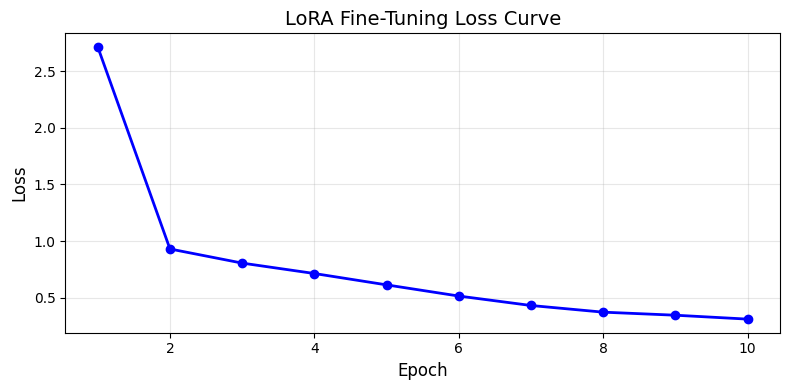

In [14]:
# Visualize training loss
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(loss_history) + 1), loss_history, "b-o", linewidth=2, markersize=6)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("LoRA Fine-Tuning Loss Curve", fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available — loss values:")
    for i, l in enumerate(loss_history):
        bar = "#" * int(l * 20)
        print(f"  Epoch {i + 1}: {l:.4f} {bar}")

In [15]:
# Test the fine-tuned model on medical questions
print("Testing fine-tuned LoRA model on medical QA...")
peft_model.eval()

# Use examples from the dev split for testing
dev_dataset = load_dataset("lavita/medical-qa-shared-task-v1-toy", split="dev")
test_samples = [dev_dataset[i] for i in range(min(3, len(dev_dataset)))]

for sample in test_samples:
    question = f"{sample['sent1']} {sample['sent2']}"
    options = ""
    for i in range(5):
        key = f"ending{i}"
        if key in sample and sample[key]:
            options += f"{i}. {sample[key]}\n"

    formatted = f"### Instruction:\nAnswer the following medical question.\n\n{question}\n{options}\n\n### Response:\n"
    inputs = tokenizer(formatted, return_tensors="pt").to(peft_model.device)

    with torch.no_grad():
        outputs = peft_model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response.split("### Response:\n")[-1].strip()
    correct = sample[f"ending{sample['label']}"]
    print(f"Q: {question[:100]}...")
    print(f"Model: {response[:100]}")
    print(f"Correct: {sample['label']}. {correct}")
    print()

Testing fine-tuned LoRA model on medical QA...
Q: A 25-year-old woman presents to the urgent care center with a one month history of intermittent ches...
Model: The correct answer is 0: Ergonovine
Correct: 0. Ergonovine

Q: A 45-year-old man is following up with his primary care doctor for follow up of his essential hypert...
Model: The correct answer is 3: Non-dihydropyridine calcium channel blockers preferentially bind to a vascu
Correct: 1. Dihydropyridine calcium channel blockers preferentially bind to a vascular smooth muscle

Q: A 43-year-old man presents to the clinic for pain with swallowing for a month.  He says that the pai...
Model: The correct answer is 0: Oral fluconazole
Correct: 0. Oral fluconazole



## 7. QLoRA: 4-bit Quantized LoRA

QLoRA combines **4-bit NormalFloat (NF4) quantization** with LoRA, enabling fine-tuning of large models on consumer GPUs with limited VRAM.

**How QLoRA Works:**
1. **Quantize** the base model to 4-bit NF4 precision (4x memory reduction)
2. **Freeze** the quantized base model — no gradients through quantized weights
3. **Add LoRA adapters** in fp16/bf16 on top of the quantized model
4. **Train only LoRA parameters** — gradients flow through dequantized weights

**Memory Savings Example (Qwen2.5-0.5B):**
| Precision | Base Model Memory | With LoRA (r=16) |
|-----------|------------------|------------------|
| fp16 | ~1.0 GB | ~1.02 GB |
| 4-bit NF4 | ~0.3 GB | ~0.32 GB |

**Key Components:**
- `BitsAndBytesConfig`: Controls quantization (4-bit, NF4, double quantization)
- `bnb_4bit_compute_dtype`: Compute dtype for quantized operations
- Double quantization: Quantize the quantization constants for extra savings

In [16]:
# QLoRA: 4-bit Quantized LoRA
import gc

# Clean up previous model to free memory
del peft_model
del base_model
gc.collect()
torch.cuda.empty_cache()

try:
    from transformers import BitsAndBytesConfig

    # Configure 4-bit quantization
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",           # NormalFloat4 quantization
        bnb_4bit_compute_dtype=torch.float16,  # Compute in fp16
        bnb_4bit_use_double_quant=True,         # Double quantization for extra savings
    )

    # Load model in 4-bit
    print("Loading Qwen2.5-0.5B in 4-bit NF4 precision...")
    qlora_base = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
    )

    # Memory comparison
    model_memory = qlora_base.get_memory_footprint() / 1e9
    print(f"\n4-bit model memory: {model_memory:.2f} GB")
    print(f"(Compare: fp16 would be ~1.0 GB)")
    print(f"Memory savings: {1.0 / model_memory:.1f}x")

    # Apply LoRA to quantized model
    qlora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        bias="none",
    )

    qlora_model = get_peft_model(qlora_base, qlora_config)
    qlora_model.print_trainable_parameters()

    # Test inference
    test_prompt = "The key advantage of QLoRA is"
    inputs = tokenizer(test_prompt, return_tensors="pt").to(qlora_model.device)

    with torch.no_grad():
        output = qlora_model.generate(**inputs, max_new_tokens=40, do_sample=False)

    print(f"\nPrompt: {test_prompt}")
    print(f"Output: {tokenizer.decode(output[0], skip_special_tokens=True)}")
    print("\nQLoRA model ready for fine-tuning on consumer GPUs!")

except ImportError:
    print("bitsandbytes not available. Install with: pip install bitsandbytes")
    print("QLoRA requires bitsandbytes for 4-bit quantization.")
    print("On AMD GPUs, use the ROCm-compatible version of bitsandbytes.")

Loading Qwen2.5-0.5B in 4-bit NF4 precision...


INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.



4-bit model memory: 0.45 GB
(Compare: fp16 would be ~1.0 GB)
Memory savings: 2.2x
trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359

Prompt: The key advantage of QLoRA is
Output: The key advantage of QLoRA is that it can be used to train models on a large number of GPUs simultaneously, which is not possible with other models. This is because QLoRA uses a technique called "gradient accumulation" to speed

QLoRA model ready for fine-tuning on consumer GPUs!


## 8. LoRA Variants: DoRA and rsLoRA

Since the original LoRA paper (2021), several variants have been developed to improve performance:

**DoRA (Weight-Decomposed Low-Rank Adaptation, 2024):**
- Decomposes weight updates into **magnitude** and **direction** components
- `W' = m · (W + AB^T) / ||W + AB^T||` where `m` is a learnable magnitude vector
- Often achieves better performance than standard LoRA, especially at low ranks
- Adopted by HuggingFace PEFT as a simple config flag

**rsLoRA (Rank-Stabilized LoRA, 2024):**
- Uses scaling factor `α / √r` instead of `α / r`
- Provides more stable training across different rank values
- Allows using higher ranks without diminishing adaptation strength

**When to use each:**
| Variant | Best For | Trade-off |
|---------|----------|-----------|
| Standard LoRA | General purpose, well-understood | Baseline |
| DoRA | Low-rank scenarios, better quality | Slightly more memory (magnitude vector) |
| rsLoRA | High-rank scenarios, stability | Minimal overhead |

In [17]:
# Compare LoRA variants using PEFT
# Reload base model for comparison
gc.collect()
torch.cuda.empty_cache()

base_model_fp16 = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)

variants = {
    "Standard LoRA": LoraConfig(
        task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
        lora_dropout=0.05, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        use_rslora=False,
    ),
    "rsLoRA": LoraConfig(
        task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
        lora_dropout=0.05, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        use_rslora=True,
    ),
    "DoRA": LoraConfig(
        task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
        lora_dropout=0.05, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        use_dora=True,
    ),
}

print("Comparing LoRA Variants:")
print(f"{'Variant':<15} {'Trainable Params':<18} {'Scaling Factor':<16} {'Extra Overhead'}")
print("=" * 70)

for name, config in variants.items():
    # Clean model copy
    import copy
    model_copy = copy.deepcopy(base_model_fp16)
    variant_model = get_peft_model(model_copy, config)

    trainable = sum(p.numel() for p in variant_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in variant_model.parameters())

    if config.use_rslora:
        scaling = f"alpha/sqrt(r) = {config.lora_alpha / (config.r ** 0.5):.2f}"
    else:
        scaling = f"alpha/r = {config.lora_alpha / config.r:.2f}"

    overhead = "magnitude vector" if config.use_dora else "none"

    print(f"{name:<15} {trainable:<18,} {scaling:<16} {overhead}")

    # Clean up
    del variant_model, model_copy
    gc.collect()

print("\nAll variants are drop-in replacements — just change the LoraConfig flags!")

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Comparing LoRA Variants:
Variant         Trainable Params   Scaling Factor   Extra Overhead
Standard LoRA   2,162,688          alpha/r = 2.00   none
rsLoRA          2,162,688          alpha/sqrt(r) = 8.00 none
DoRA            2,211,840          alpha/r = 2.00   magnitude vector

All variants are drop-in replacements — just change the LoraConfig flags!


## 9. Save, Load, and Merge LoRA Adapters

A critical workflow in production: training adapters, saving them, and deploying efficiently.

**Workflow:**
1. **Save**: Only save LoRA adapter weights (tiny, ~MBs) — not the full model
2. **Load**: Reload adapter onto the same or different base model
3. **Merge**: Combine LoRA weights into base model for inference (no adapter overhead)
4. **Multi-adapter**: Switch between task-specific adapters on the same base model

**Benefits:**
- **Storage**: 100 adapters for different tasks = ~100MB vs. 100 full models = ~100GB
- **Deployment**: Merged model has zero inference overhead from LoRA
- **Flexibility**: Hot-swap adapters at runtime for multi-task serving

In [18]:
# Save, Load, and Merge LoRA Adapters
import os
import shutil

# Reload a fresh model for this demo
gc.collect()
torch.cuda.empty_cache()

fresh_base = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)

save_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=8, lora_alpha=16,
    lora_dropout=0.05, target_modules=["q_proj", "v_proj"],
)
save_model = get_peft_model(fresh_base, save_config)

# === 1. Save Adapter ===
adapter_path = "./lora_adapter_demo"
save_model.save_pretrained(adapter_path)

# Check saved files
print("Saved adapter files:")
for f in os.listdir(adapter_path):
    size = os.path.getsize(os.path.join(adapter_path, f)) / 1024
    print(f"  {f}: {size:.1f} KB")

adapter_size = sum(
    os.path.getsize(os.path.join(adapter_path, f))
    for f in os.listdir(adapter_path)
) / (1024 * 1024)
print(f"\nTotal adapter size: {adapter_size:.2f} MB")
print(f"(Compare: full model is ~1000 MB)")

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Saved adapter files:
  adapter_model.safetensors: 2124.2 KB
  adapter_config.json: 0.9 KB
  README.md: 5.1 KB

Total adapter size: 2.08 MB
(Compare: full model is ~1000 MB)


In [19]:
# === 2. Load Adapter onto a Fresh Base Model ===
print("Loading adapter onto a fresh base model...")

fresh_base_2 = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
)

# Load adapter using PeftModel.from_pretrained
loaded_model = PeftModel.from_pretrained(fresh_base_2, adapter_path)

print(f"Adapter loaded successfully!")
loaded_model.print_trainable_parameters()

# === 3. Merge Adapter into Base Model ===
print("\nMerging LoRA weights into base model...")
merged_model = loaded_model.merge_and_unload()

# Verify merged model has no LoRA layers
lora_layers_after = sum(1 for name, _ in merged_model.named_modules() if "lora" in name.lower())
print(f"LoRA layers after merge: {lora_layers_after} (should be 0)")
print(f"Merged model is a standard model — no adapter overhead at inference!")

# Test merged model
test_input = tokenizer("Hello, how are you?", return_tensors="pt").to(merged_model.device)
with torch.no_grad():
    out = merged_model.generate(**test_input, max_new_tokens=20)
print(f"\nMerged model output: {tokenizer.decode(out[0], skip_special_tokens=True)}")

# Cleanup demo files
shutil.rmtree(adapter_path, ignore_errors=True)
print("\nDemo adapter files cleaned up.")

Loading adapter onto a fresh base model...


INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Adapter loaded successfully!
trainable params: 0 || all params: 494,573,440 || trainable%: 0.0000

Merging LoRA weights into base model...
LoRA layers after merge: 0 (should be 0)
Merged model is a standard model — no adapter overhead at inference!

Merged model output: Hello, how are you? I'm a beginner in Python and I'm trying to create a program that can find the maximum value

Demo adapter files cleaned up.


---

## Conclusions

### Technical Concepts Learned
- **Low-Rank Decomposition**: Understanding ΔW = A × B^T factorization for parameter-efficient weight updates
- **LoRA Initialization**: Gaussian initialization for A matrix, zero initialization for B to ensure stable training start
- **Parameter Freezing**: Keeping base model weights frozen while only training low-rank adaptation matrices
- **Rank and Alpha Selection**: Controlling adaptation capacity (rank) and strength (alpha/rank scaling factor)
- **Integration Strategies**: Applying LoRA selectively to different layers (all, output-only, attention layers)
- **PEFT Ecosystem**: Using HuggingFace PEFT library for production-grade LoRA on real LLMs
- **QLoRA**: Combining 4-bit NF4 quantization with LoRA for consumer GPU fine-tuning
- **LoRA Variants**: DoRA (weight-decomposed), rsLoRA (rank-stabilized) — drop-in improvements via config flags
- **Adapter Workflow**: Save/load/merge adapters for efficient storage and deployment

### 2026 LoRA Landscape
- **Standard Practice**: LoRA (and QLoRA) is the default fine-tuning method for most LLM practitioners
- **Ecosystem**: PEFT + TRL + bitsandbytes form the standard fine-tuning stack
- **Model Support**: All major architectures (Llama, Qwen, Mistral, Phi, etc.) support LoRA out of the box
- **Hardware**: QLoRA enables 7B+ model fine-tuning on 16GB consumer GPUs; 70B+ on 48GB GPUs
- **Variants**: DoRA and rsLoRA are production-ready and available as simple config flags

### Experiment Further
- Fine-tune Qwen2.5-1.5B or Llama-3.2-3B with QLoRA on a custom dataset
- Compare DoRA vs. standard LoRA on a classification task with measured accuracy
- Implement multi-adapter serving (multiple LoRA adapters on one base model)
- Try LoRA+ (different learning rates for A and B matrices) for faster convergence
- Experiment with AdaLoRA for automatic rank allocation during training
- Apply LoRA to vision transformers (ViT) or multimodal models

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT
